# Laboratorio de regresión - 4

|                |   |
:----------------|---|
| **Nombre**     | Carlos Enrique Nieves Ochoa |
| **Fecha**      | 14 de septiembre de 2026 |
| **Expediente** | 758210 |

## Modelos penalizados

Hasta ahora la función de costo que usamos para decidir qué tan bueno es nuestro modelo al momento de ajustar es:

$$ \text{RSS} = \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - \hat{y_i})^2 $$

Dado que los errores obtenidos son una combinación de sesgo y varianza, puede ser que se sesgue un parámetro para minimizar el error. Esto significa que el modelo puede decidir que la salida no sea una combinación de los factores, sino una fuerte predilección sobre uno de los factores solamente. 

E.g. se quiere ajustar un modelo

$$ \hat{z} = \hat{\beta_0} + \hat{\beta_1} x + \hat{\beta_2} y $$

Se ajusta el modelo y se decide que la mejor decisión es $\hat{\beta_1} = 10000$ y $\hat{\beta_2}=50$. Considera limitaciones de problemas reales:
- Quizás los parámetros son ajustes de maquinaria que se deben realizar para conseguir el mejor producto posible, y que $10000$ sea imposible de asignar.
- Quizás los datos actuales están sesgados y sólo hacen parecer que uno de los factores importa más que el otro.

Una de las formas en las que se puede mitigar este problema es penalizando a los parámetros del modelo, cambiando la función de costo:

$$ \text{RSS}_{L2} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p \hat{\beta_j}^2 $$

El *L2* significa que se está agregando una penalización de segundo orden. Lo que hace esta penalización es que los factores ahora sólo tendrán permitido crecer si hay una reducción al menos proporcional en el error (sacrificamos sesgo, pero reducimos la varianza).

Asimismo, existe la penalización *L1*

$$ \text{RSS}_{L1} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p |\hat{\beta_j}| $$

A las penalizaciones *L2* y *L1* se les conoce también como Ridge y Lasso, respectivamente.

Para realizar una regresión con penalización de Ridge o de Lasso usamos el objeto `Ridge(alpha=?)` o `Lasso(alpha=?)` en lugar de `LinearRegression()` de `sklearn`.

Utiliza el dataset de publicidad (Advertising.csv), utiliza train-test-split de 70/30 y realiza 3 regresiones múltiples:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

1. Sin penalización
2. Con penalización L2
3. Con penalización L1

¿Qué puedes observar al ajustar los valores de `alpha`? 

Compara los resultados de los coeficientes utilizando valores diferentes de $\alpha$ y los $R^2$ resultantes.



## Preparación de los datos

In [1]:
# Librerías y datos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

df = pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


El archivo contiene la inversión en TV, radio y newspaper, además de las ventas obtenidas. La primera columna sólo identifica cada registro, por lo que no se utiliza como factor.

In [2]:
# Variables del modelo

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

# Separación de 70 % para entrenamiento y 30 % para prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])

Datos de entrenamiento: 140
Datos de prueba: 60


Se utilizaron 140 observaciones para entrenar los modelos y 60 para probarlos. El valor random_state=42 permite obtener la misma separación cada vez que se ejecute el archivo.

In [3]:
# Estandarizar los factores

scaler = StandardScaler()
scaler.fit(X_train)

X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Estandaricé los factores porque sus escalas son diferentes y la penalización depende del tamaño de los coeficientes. El escalador se ajustó únicamente con los datos de entrenamiento para no utilizar información de la prueba antes de evaluar los modelos.

## 1. Regresión sin penalización

In [4]:
# Modelo sin penalización

lin = LinearRegression()
lin.fit(X_train_s, y_train)

sin = pd.DataFrame({
    "Modelo": ["Sin penalización"],
    "alpha": [0],
    "B0": [lin.intercept_],
    "TV": [lin.coef_[0]],
    "radio": [lin.coef_[1]],
    "newspaper": [lin.coef_[2]],
    "R2 entrenamiento": [lin.score(X_train_s, y_train)],
    "R2 prueba": [lin.score(X_test_s, y_test)]
})

display(sin.round(6))

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Sin penalización,0,14.497143,3.683341,2.906252,0.141948,0.905516,0.860947


El modelo sin penalización obtuvo un R² de 0.9055 en entrenamiento y 0.8609 en prueba. Esto significa que explica aproximadamente el 86.1 % de las ventas de los datos que no utilizó para entrenarse. Como los factores están estandarizados, puedo comparar directamente sus coeficientes: TV tiene el mayor peso con 3.68, después aparece radio con 2.91 y newspaper aporta muy poco con 0.14.

## 2. Regresión Ridge con penalización L2

In [5]:
# Probar Ridge con diferentes valores de alpha

alphas = [0.01, 0.1, 1, 10, 100]
filas = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_s, y_train)

    filas.append([
        "Ridge", a, ridge.intercept_,
        ridge.coef_[0], ridge.coef_[1], ridge.coef_[2],
        ridge.score(X_train_s, y_train),
        ridge.score(X_test_s, y_test)
    ])

res_ridge = pd.DataFrame(filas, columns=[
    "Modelo", "alpha", "B0", "TV", "radio", "newspaper",
    "R2 entrenamiento", "R2 prueba"
])

display(res_ridge.round(6))

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Ridge,0.01,14.497143,3.683090,2.906037,0.142020,0.905516,0.860946
1,Ridge,0.10,14.497143,3.680830,2.904099,0.142665,0.905516,0.860938
2,Ridge,1.00,14.497143,3.658385,2.884879,0.149011,0.905475,0.860823
3,Ridge,10.00,14.497143,3.448126,2.707470,0.203134,0.901877,0.856520
4,Ridge,100.00,14.497143,2.190561,1.711322,0.349759,0.762821,0.711173


Con valores de alpha entre 0.01 y 1, Ridge produce resultados casi iguales al modelo sin penalización y mantiene un R² de prueba cercano a 0.861. Al aumentar alpha, los coeficientes de TV y radio se reducen y el rendimiento comienza a bajar; con alpha=100, el R² de prueba disminuye hasta 0.7112. Ridge controla el tamaño general de los coeficientes, pero no elimina factores llevándolos exactamente a cero.

## 3. Regresión Lasso con penalización L1

In [6]:
# Probar Lasso con diferentes valores de alpha

filas = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_s, y_train)

    filas.append([
        "Lasso", a, lasso.intercept_,
        lasso.coef_[0], lasso.coef_[1], lasso.coef_[2],
        lasso.score(X_train_s, y_train),
        lasso.score(X_test_s, y_test)
    ])

res_lasso = pd.DataFrame(filas, columns=[
    "Modelo", "alpha", "B0", "TV", "radio", "newspaper",
    "R2 entrenamiento", "R2 prueba"
])

display(res_lasso.round(6))

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Lasso,0.01,14.497143,3.674033,2.899384,0.134602,0.905507,0.861413
1,Lasso,0.10,14.497143,3.590306,2.837473,0.068525,0.904620,0.864626
2,Lasso,1.00,14.497143,2.746712,2.016501,0.000000,0.833336,0.805637
3,Lasso,10.00,14.497143,0.000000,0.000000,0.000000,0.000000,-0.091676
4,Lasso,100.00,14.497143,0.000000,0.000000,0.000000,0.000000,-0.091676


Lasso con alpha=0.01 casi no cambia el modelo. Con alpha=0.1, el coeficiente de newspaper baja a 0.07 y el R² de prueba aumenta ligeramente hasta 0.8646, que es el mejor resultado de esta comparación. Cuando alpha=1, Lasso elimina newspaper al convertir su coeficiente en cero, pero el R² baja a 0.8056. Con valores de 10 y 100 elimina los tres factores y el resultado es peor que predecir únicamente el promedio.

## Comparación de los tres modelos

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Sin penalización,0.00,14.497143,3.683341,2.906252,0.141948,0.905516,0.860947
1,Ridge,0.01,14.497143,3.683090,2.906037,0.142020,0.905516,0.860946
2,Ridge,0.10,14.497143,3.680830,2.904099,0.142665,0.905516,0.860938
3,Ridge,1.00,14.497143,3.658385,2.884879,0.149011,0.905475,0.860823
4,Ridge,10.00,14.497143,3.448126,2.707470,0.203134,0.901877,0.856520
5,Ridge,100.00,14.497143,2.190561,1.711322,0.349759,0.762821,0.711173
6,Lasso,0.01,14.497143,3.674033,2.899384,0.134602,0.905507,0.861413
7,Lasso,0.10,14.497143,3.590306,2.837473,0.068525,0.904620,0.864626
8,Lasso,1.00,14.497143,2.746712,2.016501,0.000000,0.833336,0.805637
9,Lasso,10.00,14.497143,0.000000,0.000000,0.000000,0.000000,-0.091676


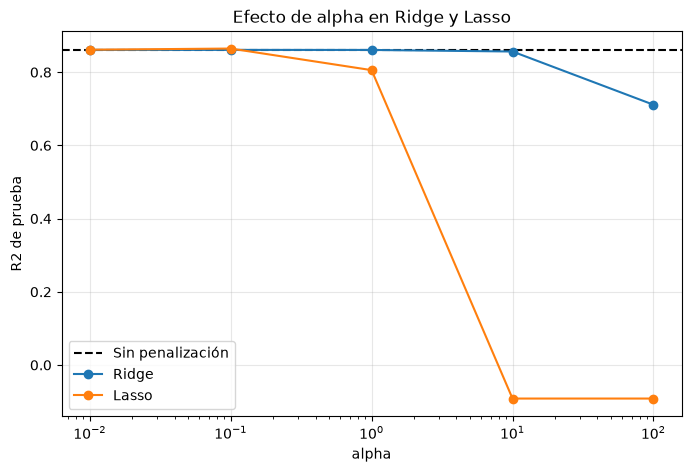

In [7]:
# Tabla con todos los resultados

comparacion = pd.concat([sin, res_ridge, res_lasso], ignore_index=True)
display(comparacion.round(6))

# Comparación del R2 de prueba

plt.figure(figsize=(8, 5))
plt.axhline(
    sin.loc[0, "R2 prueba"], color="black", linestyle="--",
    label="Sin penalización"
)
plt.plot(
    res_ridge["alpha"], res_ridge["R2 prueba"],
    marker="o", label="Ridge"
)
plt.plot(
    res_lasso["alpha"], res_lasso["R2 prueba"],
    marker="o", label="Lasso"
)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R2 de prueba")
plt.title("Efecto de alpha en Ridge y Lasso")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Al aumentar alpha, la penalización se vuelve más fuerte y limita cada vez más los coeficientes. Una penalización pequeña conserva casi toda la capacidad del modelo y puede mejorar ligeramente su resultado en datos nuevos, pero una penalización demasiado grande provoca subajuste porque simplifica el modelo en exceso. Entre los valores probados, elegiría Lasso con alpha=0.1, ya que obtuvo el mayor R² de prueba, 0.8646, y redujo bastante el peso de newspaper. La mejora frente al modelo sin penalización, cuyo R² fue 0.8609, es pequeña, por lo que estos datos no necesitan una penalización fuerte.